# 02 - Exploratory Data Analysis

## Objective

This notebook performs EDA on the final cleaned dataset generated in Week 2 Day 5.

It validates class balance, feature distributions, outlier treatment, correlations, separability with selected feature pairs and PCA 2D projection before ML.

The EDA is not decorative: it verifies whether the selected L3/L4 features provide meaningful separation between traffic categories.

In [1]:
from pathlib import Path
import json

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
FIGURES_DIR = PROJECT_ROOT / 'docs' / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

dataset_path = PROCESSED_DIR / 'dataset.csv'
scaled_path = PROCESSED_DIR / 'dataset_scaled.csv'
features_path = PROCESSED_DIR / 'feature_columns.json'

df = pd.read_csv(dataset_path)
df_scaled = pd.read_csv(scaled_path)

with features_path.open('r', encoding='utf-8') as file:
    feature_columns = json.load(file)['feature_columns']

print('Dataset shape:', df.shape)
print('Scaled dataset shape:', df_scaled.shape)
print('Feature count:', len(feature_columns))

df.head()

Dataset shape: (491, 41)
Scaled dataset shape: (491, 41)
Feature count: 40


,protocol,bidirectional_duration_ms,bidirectional_packets,bidirectional_bytes,src2dst_packets,dst2src_packets,src2dst_bytes,dst2src_bytes,bidirectional_mean_ps,bidirectional_syn_packets,bidirectional_ack_packets,bidirectional_rst_packets,bidirectional_fin_packets,bidirectional_psh_packets,bytes_asymmetry_ratio,packets_asymmetry_ratio,bidirectional_packets_per_ms,bytes_per_packet,syn_ack_ratio_nfstream,manual_packet_count,iat_mean_ms,iat_std_ms,iat_cv,rtt_estimate_ms,tcp_window_min,tcp_window_max,tcp_window_mean,tcp_window_var,syn_ack_ratio_manual,duration_zero_flag,syn_ack_ratio_nfstream_missing,iat_mean_ms_missing,iat_std_ms_missing,iat_cv_missing,rtt_estimate_ms_missing,tcp_window_min_missing,tcp_window_max_missing,tcp_window_mean_missing,tcp_window_var_missing,syn_ack_ratio_manual_missing,label
0,17,0,1,42,1,0,42,0,42.0,0,0,0,0,0,43.000000,2.0,1.0,42.0,1.0,1,0.012875,0.0,0.0,0.026941,0.0,1024.0,512.0,262144.0,1.0,1,1,1,1,1,1,1,1,1,1,1,udp_scan
1,6,1,2,154,1,1,112,54,81.5,1,1,0,0,0,1.072727,1.4,2.0,81.5,1.0,2,0.087680,0.0,0.0,0.026941,0.0,1024.0,512.0,262144.0,1.0,0,0,0,0,0,0,0,0,0,0,0,normal
2,17,0,1,42,1,0,42,0,42.0,0,0,0,0,0,43.000000,2.0,1.0,42.0,1.0,1,0.012875,0.0,0.0,0.026941,0.0,1024.0,512.0,262144.0,1.0,1,1,1,1,1,1,1,1,1,1,1,udp_scan
3,17,0,1,42,1,0,42,0,42.0,0,0,0,0,0,43.000000,2.0,1.0,42.0,1.0,1,0.012875,0.0,0.0,0.026941,0.0,1024.0,512.0,262144.0,1.0,1,1,1,1,1,1,1,1,1,1,1,udp_scan
4,17,0,1,42,1,0,42,0,42.0,0,0,0,0,0,43.000000,2.0,1.0,42.0,1.0,1,0.012875,0.0,0.0,0.026941,0.0,1024.0,512.0,262144.0,1.0,1,1,1,1,1,1,1,1,1,1,1,udp_scan


## Class balance

This check verifies whether the final dataset is balanced enough for ML experiments.

label
udp_scan      129
normal        129
syn_scan      129
icmp_flood     61
port_sweep     43
Name: count, dtype: int64

max/min class ratio: 3.0


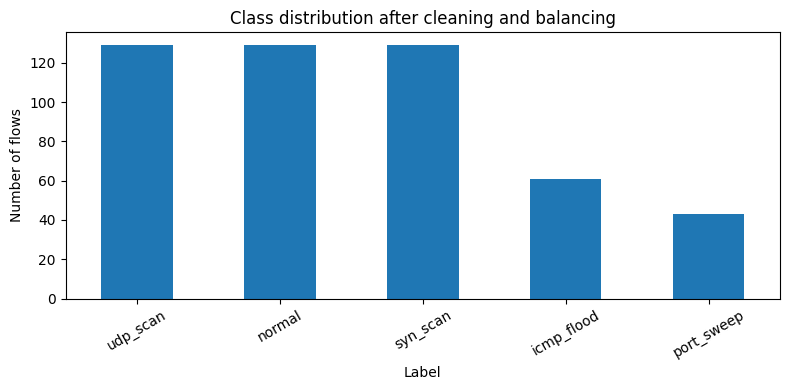

In [2]:
label_counts = df['label'].value_counts()
display(label_counts)

ratio = label_counts.max() / label_counts.min()
print('max/min class ratio:', round(ratio, 3))

plt.figure(figsize=(8, 4))
label_counts.plot(kind='bar')
plt.title('Class distribution after cleaning and balancing')
plt.xlabel('Label')
plt.ylabel('Number of flows')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_class_distribution.png', dpi=150)
plt.show()

## Missing values

The final ML datasets should not contain NaN values. Missing indicators preserve the information that some protocol-specific features were not applicable.

In [3]:
nan_dataset = int(df.isna().sum().sum())
nan_scaled = int(df_scaled.isna().sum().sum())

print('NaN total in dataset.csv:', nan_dataset)
print('NaN total in dataset_scaled.csv:', nan_scaled)

missing_indicator_cols = [col for col in df.columns if col.endswith('_missing')]
print('Missing indicator columns:', missing_indicator_cols)

NaN total in dataset.csv: 0
NaN total in dataset_scaled.csv: 0
Missing indicator columns: ['syn_ack_ratio_nfstream_missing', 'iat_mean_ms_missing', 'iat_std_ms_missing', 'iat_cv_missing', 'rtt_estimate_ms_missing', 'tcp_window_min_missing', 'tcp_window_max_missing', 'tcp_window_mean_missing', 'tcp_window_var_missing', 'syn_ack_ratio_manual_missing']


## Feature statistics by label

This table is useful for the technical report because it shows whether the main features behave differently across classes.

In [4]:
key_features = [
    'bidirectional_duration_ms',
    'bidirectional_packets',
    'bidirectional_bytes',
    'iat_mean_ms',
    'iat_cv',
    'syn_ack_ratio_manual',
    'bidirectional_packets_per_ms',
    'bidirectional_mean_ps',
]

available_key_features = [col for col in key_features if col in df.columns]

stats_by_label = (
    df.groupby('label')[available_key_features]
    .agg(['count', 'mean', 'median', 'std'])
    .round(4)
)

display(stats_by_label)

bidirectional_duration_ms                        bidirectional_packets                       bidirectional_bytes                           iat_mean_ms                         iat_cv       \
                               count    mean median     std                 count    mean median    std               count      mean median      std       count    mean  median     std  count mean   
label                                                                                                                                                                                                   
icmp_flood                        61  0.0164    0.0  0.1280                    61  1.0164    1.0  0.128                  61   78.2623   88.0  14.7715          61  0.0128  0.0129  0.0008     61  0.0   
normal                           129  0.7829    1.0  0.4138                   129  1.9922    2.0  0.088                 129  153.9690  154.0   0.3522         129  0.0757  0.0877  0.0219    129  0.0   
port_sweep                        43  0.2093    0.0  0.4116                    43  2.0000    2.0  0.000                  43  121.7674  112.0  17.9534          43  0.0501  0.0479  0.0303     43  0.0   
syn_scan                         129  0.0233    0.0  0.1513                   129  2.0000    2.0  0.000                 129  112.0000  112.0   0.0000         129  0.0132  0.0119  0.0067    129  0.0   
udp_scan                         129  0.0000    0.0  0.0000                   129  1.0000    1.0  0.000                 129   42.6124   42.0   4.8995         129  0.0129  0.0129  0.0000    129  0.0   

                       syn_ack_ratio_manual                  bidirectional_packets_per_ms                        bidirectional_mean_ps                          
           median  std                count mean median  std                        count    mean median     std                 count     mean median     std  
label                                                                                                                                                           
icmp_flood    0.0  0.0                   61  1.0    1.0  0.0                           61  1.0164    1.0  0.1280                    61  73.2295   66.0  8.7515  
normal        0.0  0.0                  129  1.0    1.0  0.0                          129  1.8431    2.0  0.3601                   129  81.3603   81.5  0.4020  
port_sweep    0.0  0.0                   43  1.0    1.0  0.0                           43  1.9767    2.0  0.1525                    43  60.1977   56.0  9.5061  
syn_scan      0.0  0.0                  129  1.0    1.0  0.0                          129  2.0000    2.0  0.0000                   129  56.0000   56.0  0.0000  
udp_scan      0.0  0.0                  129  1.0    1.0  0.0                          129  1.0000    1.0  0.0000                   129  42.6085   42.0  4.8682

## Histograms by class

Histograms allow us to inspect whether each feature has class-specific distributions.

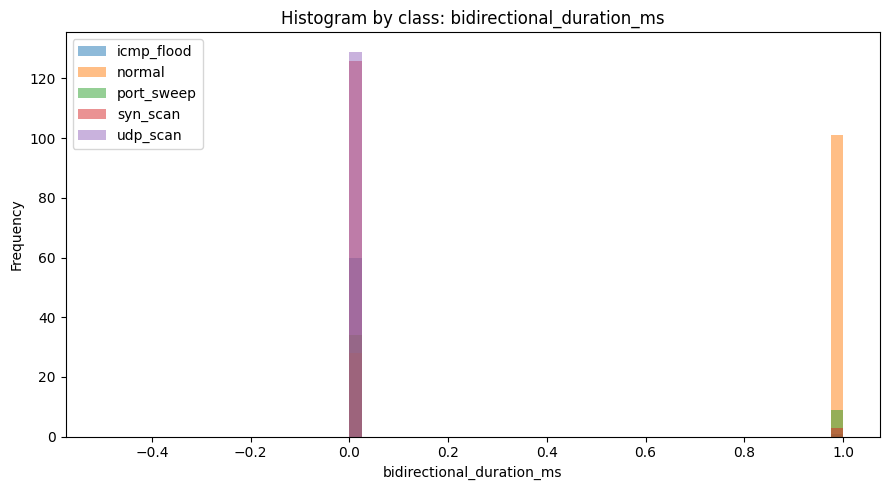

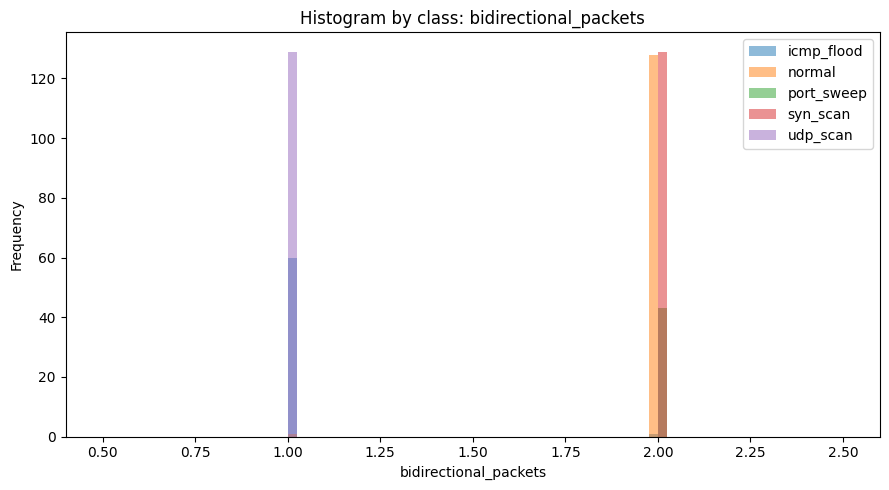

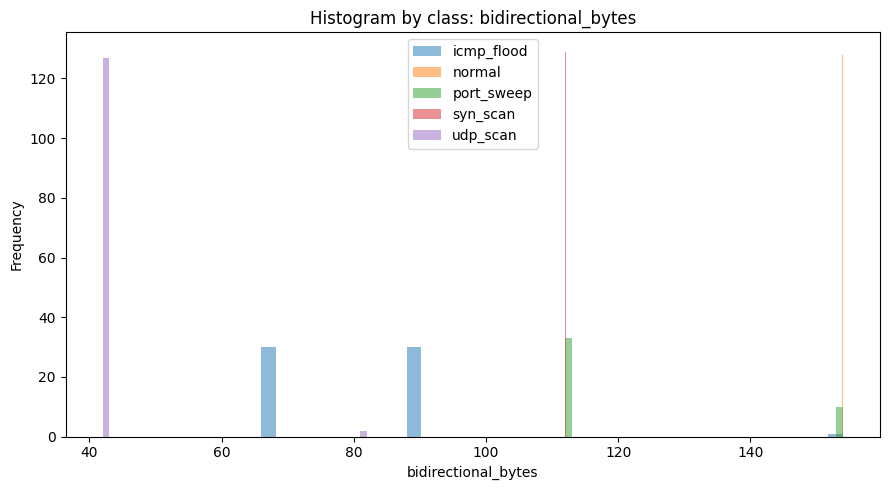

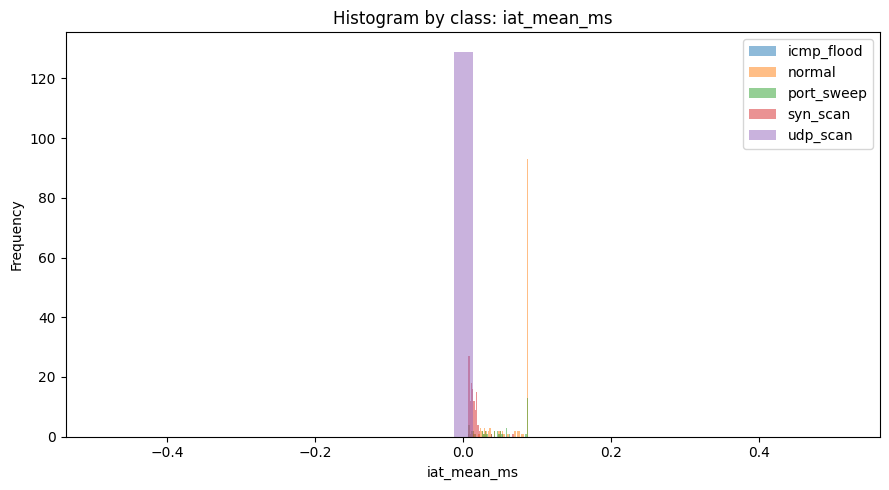

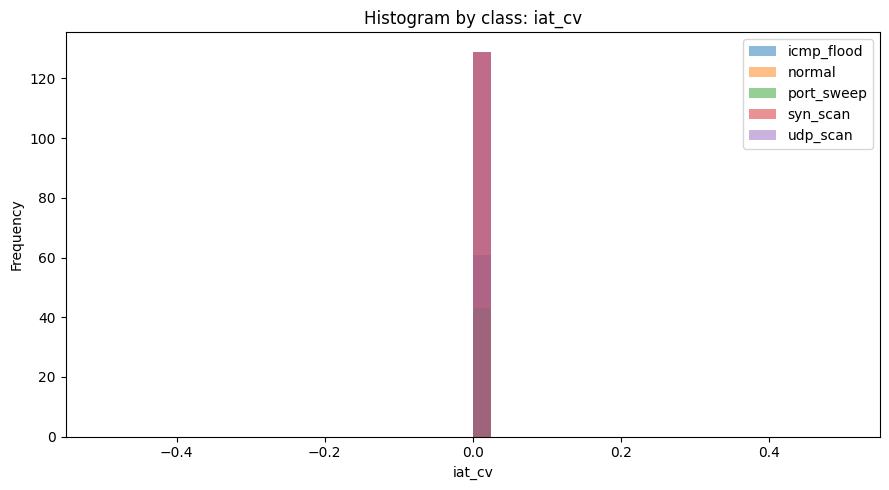

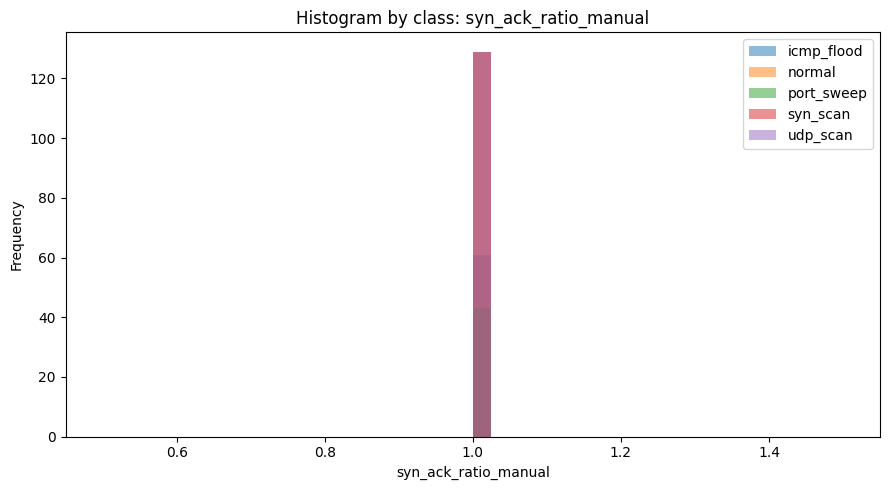

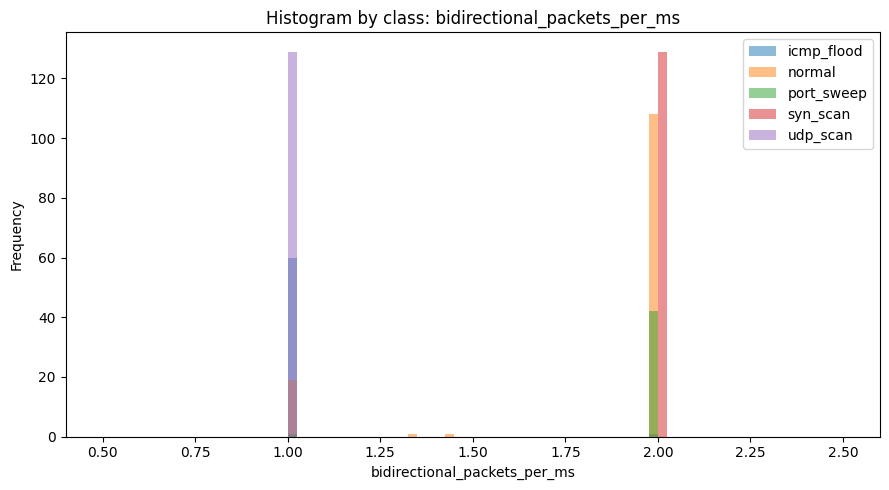

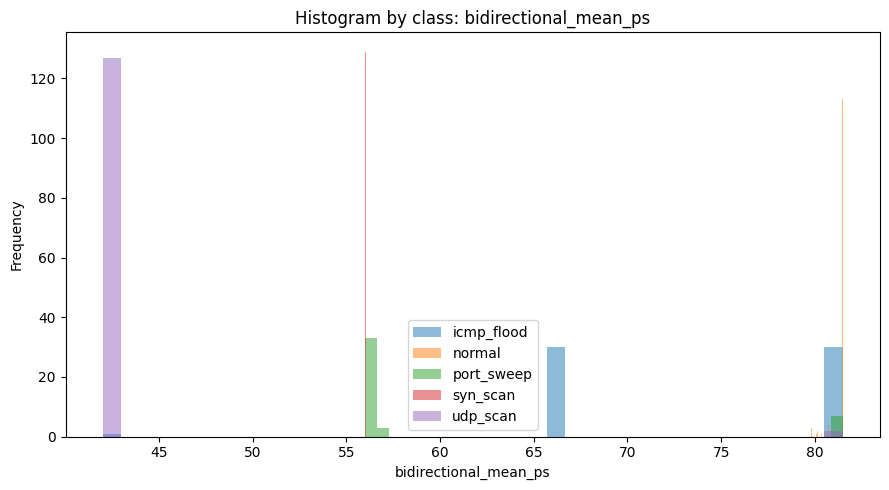

In [5]:
for col in available_key_features:
    plt.figure(figsize=(9, 5))
    for label in sorted(df['label'].unique()):
        subset = df[df['label'] == label][col]
        plt.hist(subset, bins=40, alpha=0.5, label=label)
    plt.title(f'Histogram by class: {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'eda_hist_{col}.png', dpi=150)
    plt.show()

## Boxplots by class

Boxplots show robust distribution differences and remaining outliers after clipping.

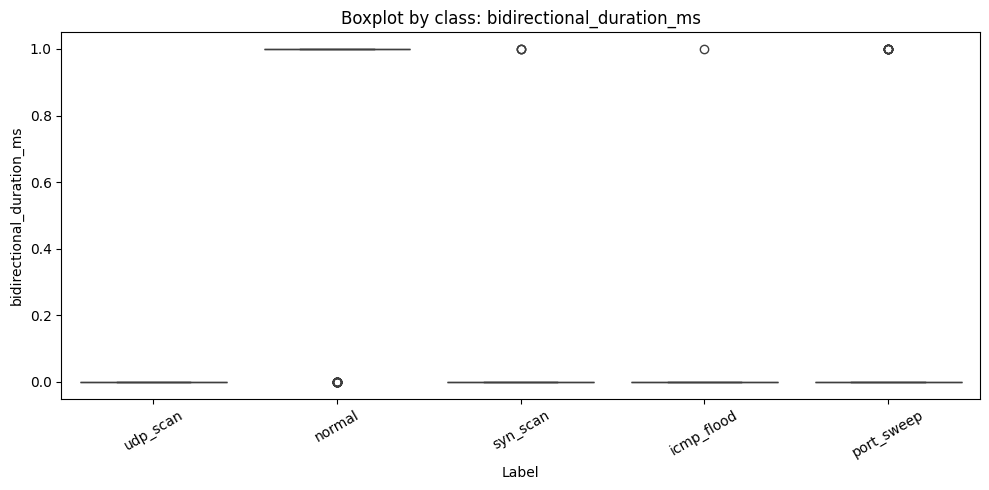

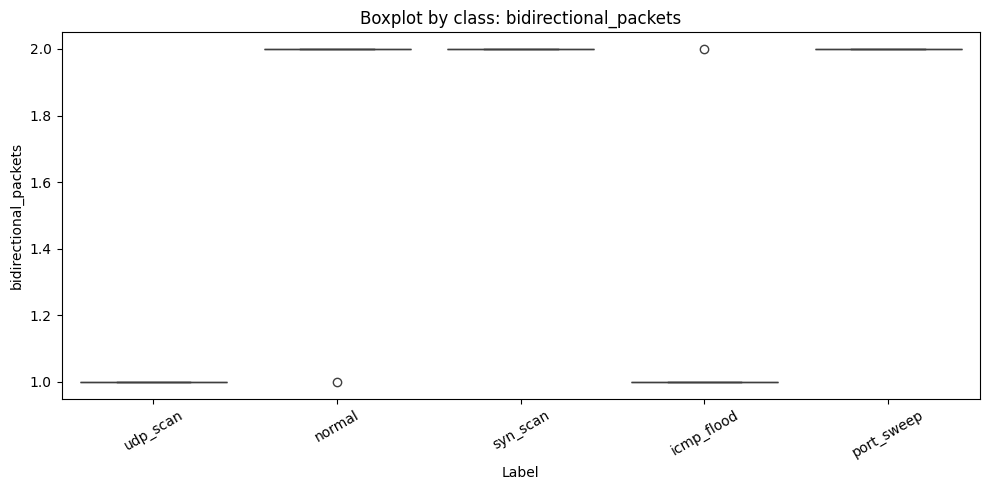

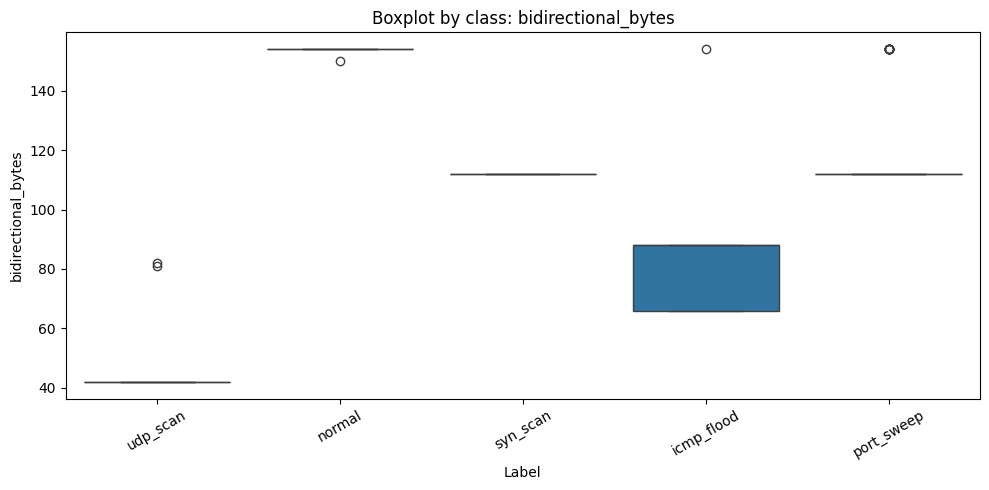

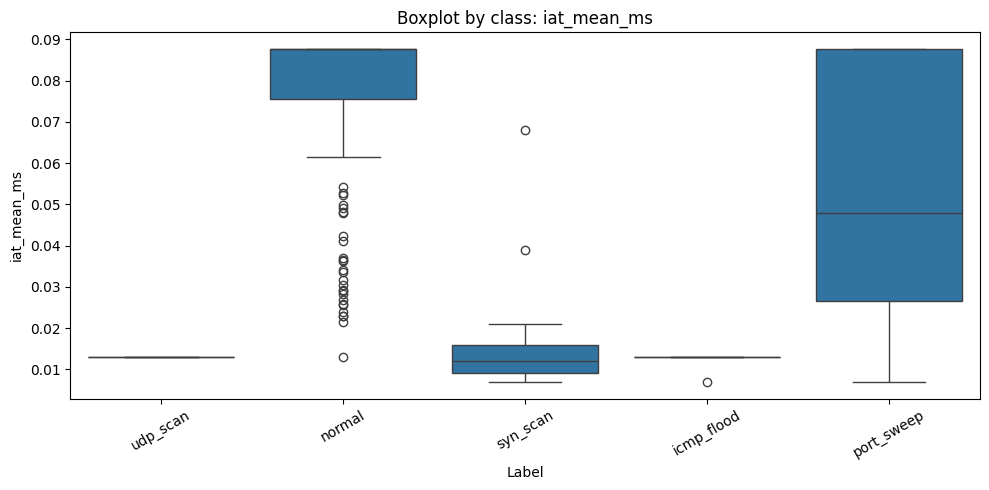

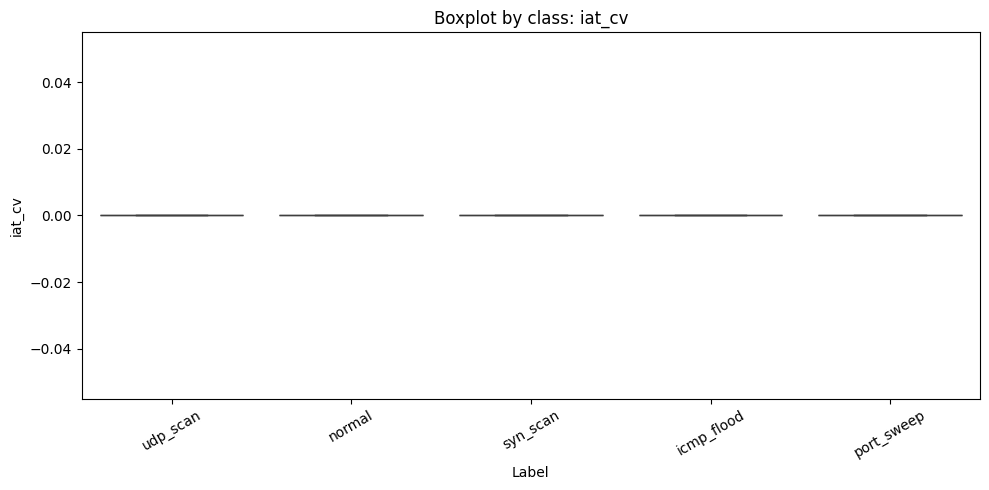

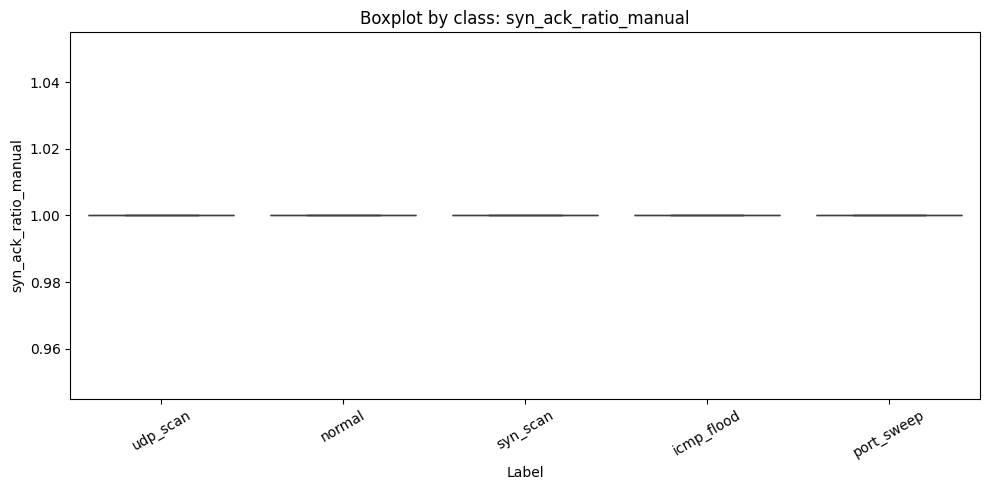

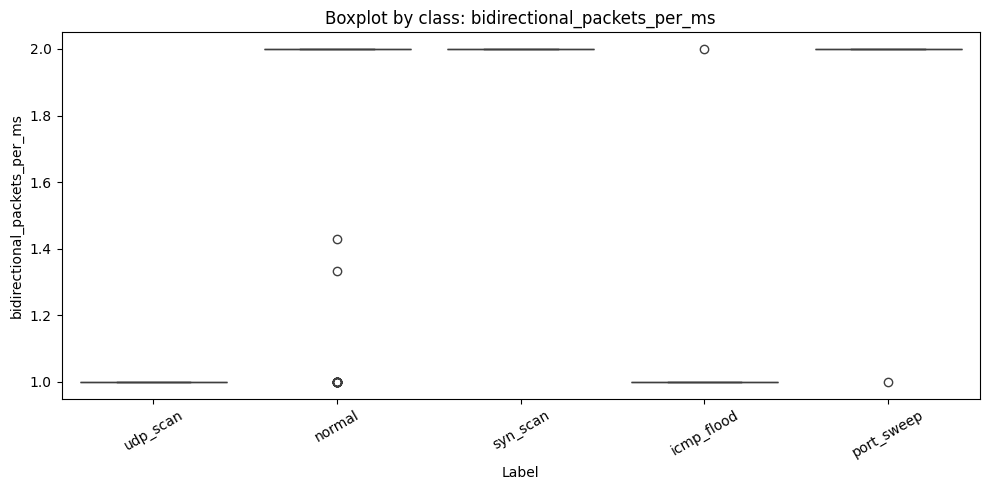

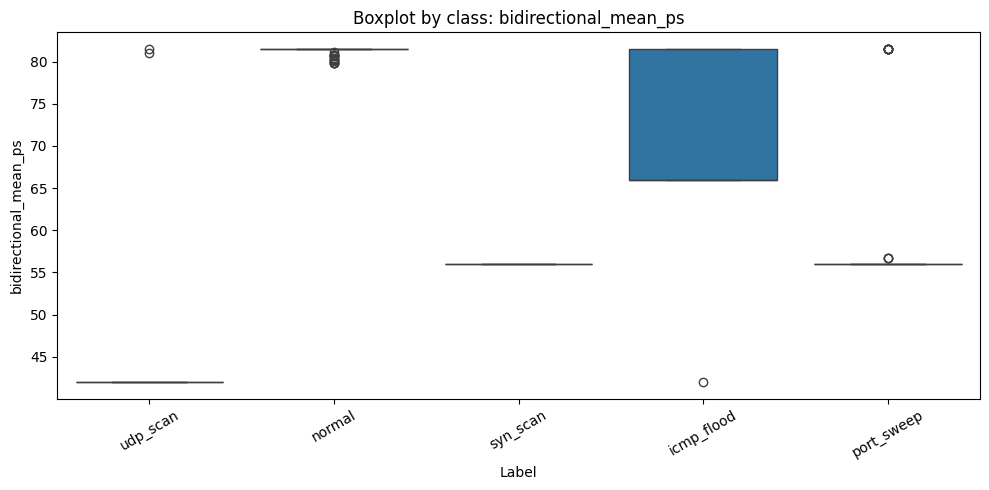

In [6]:
for col in available_key_features:
    plt.figure(figsize=(10, 5))
    sns.boxplot(data=df, x='label', y=col)
    plt.title(f'Boxplot by class: {col}')
    plt.xlabel('Label')
    plt.ylabel(col)
    plt.xticks(rotation=30)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / f'eda_box_{col}.png', dpi=150)
    plt.show()

## IAT CV vs SYN/ACK ratio

This scatter plot validates two protocol-aware features: timing variability and TCP handshake imbalance.

If classes overlap completely, the extraction process should be reviewed before ML.

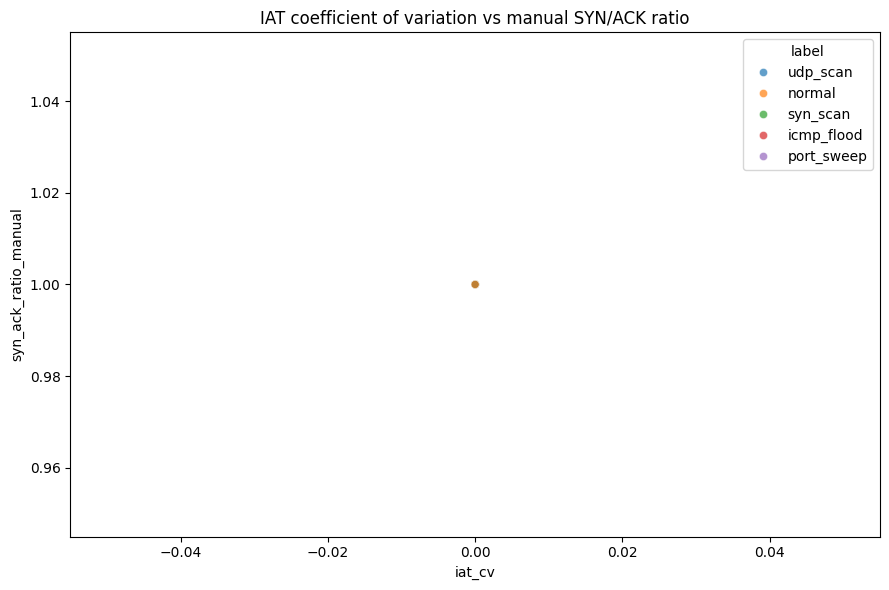

In [7]:
x_col = 'iat_cv'
y_col = 'syn_ack_ratio_manual'

if x_col in df.columns and y_col in df.columns:
    plt.figure(figsize=(9, 6))
    sns.scatterplot(
        data=df,
        x=x_col,
        y=y_col,
        hue='label',
        alpha=0.7,
        s=35,
    )
    plt.title('IAT coefficient of variation vs manual SYN/ACK ratio')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / 'eda_scatter_iat_cv_syn_ack_ratio.png', dpi=150)
    plt.show()
else:
    print('Required columns not available')

## Correlation heatmap

Highly correlated features are expected because packets, bytes and derived rates are related. This plot helps identify redundancy before ML.

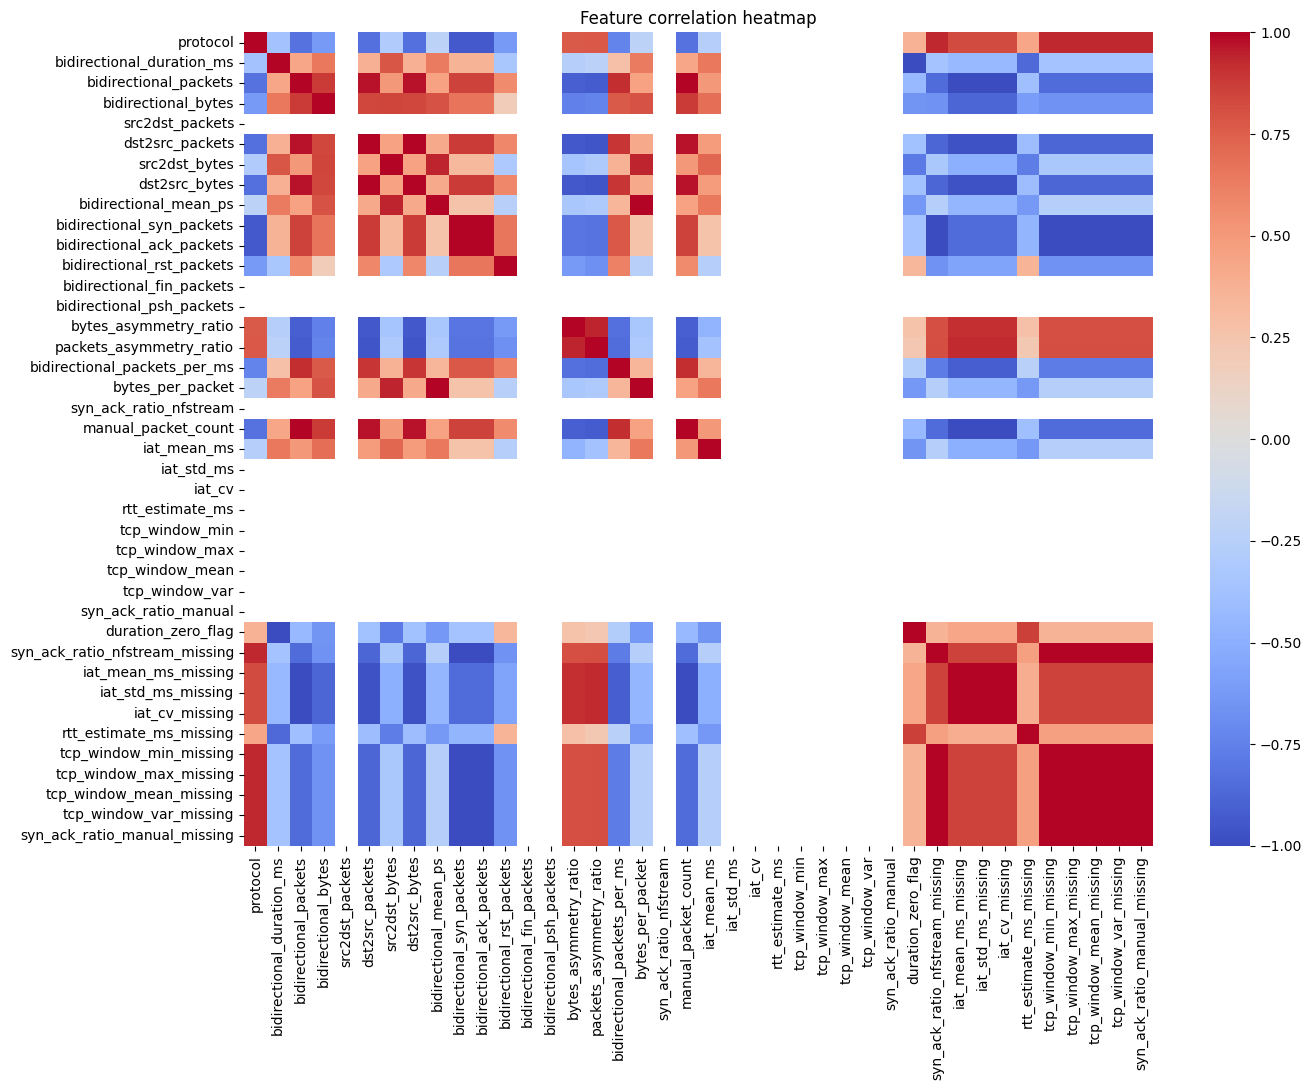

In [8]:
corr_features = [col for col in feature_columns if col in df.columns]
corr = df[corr_features].corr(numeric_only=True)

plt.figure(figsize=(14, 11))
sns.heatmap(corr, cmap='coolwarm', center=0, square=False)
plt.title('Feature correlation heatmap')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_correlation_heatmap.png', dpi=150)
plt.show()

## PCA 2D projection

PCA is applied to the scaled dataset to visualize whether the selected features provide separability before clustering or classification.

Explained variance ratio: [0.70070185 0.18000608]
Total explained variance: 0.8807079331474301


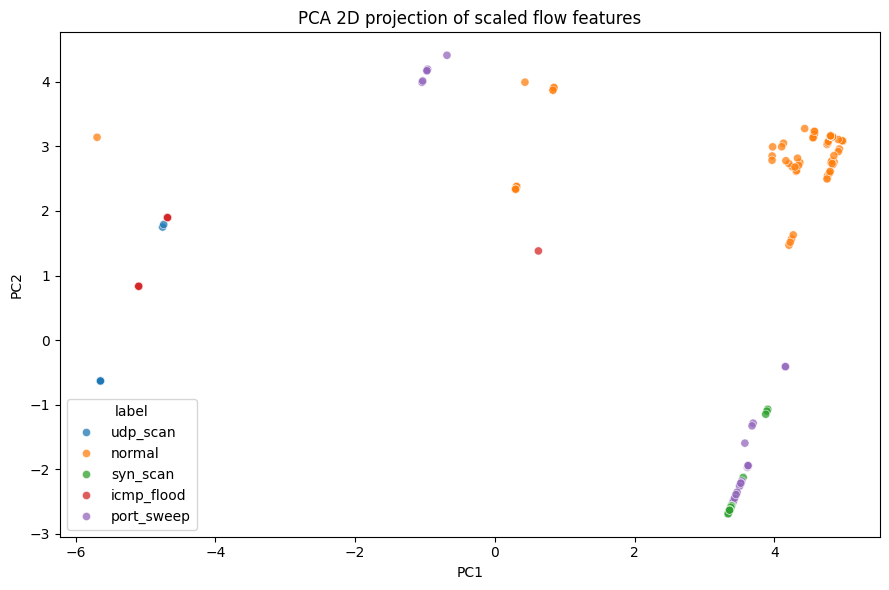

In [9]:
X_scaled = df_scaled[feature_columns].values

pca = PCA(n_components=2, random_state=42)
components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    'PC1': components[:, 0],
    'PC2': components[:, 1],
    'label': df_scaled['label'],
})

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Total explained variance:', pca.explained_variance_ratio_.sum())

plt.figure(figsize=(9, 6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='label', alpha=0.75, s=35)
plt.title('PCA 2D projection of scaled flow features')
plt.tight_layout()
plt.savefig(FIGURES_DIR / 'eda_pca_2d.png', dpi=150)
plt.show()

## EDA conclusion

The EDA validates whether the final dataset is suitable for ML.

Main checks:

1. No NaN values remain in the final datasets.
2. Class imbalance is controlled.
3. Main L3/L4 features show class-dependent distributions.
4. PCA provides a first visual indication of separability.

The next step is to use dataset_scaled.csv for K-Means clustering and dataset.csv or dataset_scaled.csv for Random Forest classification.